<a href="https://colab.research.google.com/github/DenisBoytsov41/tutors-sentiment-coursework/blob/main/notebooks/01_data_inventory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01_data_understanding.ipynb

## Этап 1. Понимание данных

Цель ноутбука:
- проверить, какие русскоязычные датасеты реально лежат в `01_data_raw`;
- понять структуру каждого источника;
- выявить текстовые, ролевые и меточные поля;
- оценить качество текстов до этапа подготовки;
- зафиксировать, какую роль каждый датасет будет играть в проекте.

## Важно
В этом ноутбуке мы:
- не обучаем модель;
- не строим финальный train/validation/test;
- не делаем агрессивную очистку текста;
- не смешиваем автоматически разные типы разметки.

Это этап **понимания данных**, а не этап моделирования.

In [ ]:
!pip -q install pandas pyarrow matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import ast
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

In [ ]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 150)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Пути проекта

In [ ]:
DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/tutors_sentiment_project")

RAW_DIR = DRIVE_PROJECT_ROOT / "01_data_raw"
INTERIM_DIR = DRIVE_PROJECT_ROOT / "02_data_interim"

SOURCE_PASSPORTS_DIR = INTERIM_DIR / "source_passports"
QC_REPORTS_DIR = INTERIM_DIR / "qc_reports"
FIGURES_DIR = QC_REPORTS_DIR / "figures"

SOURCE_PASSPORTS_DIR.mkdir(parents=True, exist_ok=True)
QC_REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("DRIVE_PROJECT_ROOT =", DRIVE_PROJECT_ROOT)
print("RAW_DIR            =", RAW_DIR)
print("INTERIM_DIR        =", INTERIM_DIR)
print("SOURCE_PASSPORTS   =", SOURCE_PASSPORTS_DIR)
print("QC_REPORTS         =", QC_REPORTS_DIR)
print("FIGURES_DIR        =", FIGURES_DIR)

DRIVE_PROJECT_ROOT = /content/drive/MyDrive/tutors_sentiment_project
RAW_DIR            = /content/drive/MyDrive/tutors_sentiment_project/01_data_raw
INTERIM_DIR        = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim
SOURCE_PASSPORTS   = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/source_passports
QC_REPORTS         = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports
FIGURES_DIR        = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports/figures


## 2. Реестр используемых русскоязычных датасетов

In [ ]:
DATASET_REGISTRY = {
    "rusentiment": {
        "folder": RAW_DIR / "rusentiment",
        "group": "sentiment_baseline",
        "priority": "core",
        "expected_usage": "базовый русскоязычный sentiment-корпус для 3-классовой тональности",
    },
    "rusentitweet": {
        "folder": RAW_DIR / "rusentitweet",
        "group": "sentiment_baseline",
        "priority": "core",
        "expected_usage": "дополнительный русскоязычный sentiment-корпус; требует дальнейшего приведения меток",
    },
    "cedr_ru": {
        "folder": RAW_DIR / "cedr_ru",
        "group": "emotion_auxiliary",
        "priority": "aux",
        "expected_usage": "дополнительный русскоязычный emotional corpus; не смешивать автоматически с 3-классовой тональностью",
    },
    "student_feedback_ru": {
        "folder": RAW_DIR / "student_feedback_ru",
        "group": "education_feedback",
        "priority": "domain",
        "expected_usage": "русские отзывы студентов по учебным курсам; доменно близкий образовательный источник",
    },
    "instructional_dialogues_ru": {
        "folder": RAW_DIR / "instructional_dialogues_ru",
        "group": "dialogue_domain",
        "priority": "aux_domain",
        "expected_usage": "небольшой вспомогательный instructional dialogue source; требует осторожной фильтрации",
    },
    "teacher_student_dialogues_ru": {
        "folder": RAW_DIR / "teacher_student_dialogues_ru",
        "group": "dialogue_domain",
        "priority": "domain_core",
        "expected_usage": "основной доменно близкий диалоговый student-teacher аналог",
    },
    "local_domain_ru": {
        "folder": RAW_DIR / "local_domain_ru",
        "group": "local_domain",
        "priority": "future_core",
        "expected_usage": "локальный корпус ИС Тьюторы; сейчас это шаблон под реальные будущие выгрузки",
    },
}

registry_df = pd.DataFrame([
    {
        "dataset_name": name,
        "folder": str(meta["folder"]),
        "group": meta["group"],
        "priority": meta["priority"],
        "expected_usage": meta["expected_usage"],
    }
    for name, meta in DATASET_REGISTRY.items()
])

display(registry_df)

,dataset_name,folder,group,priority,expected_usage
0,rusentiment,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/rusentiment,sentiment_baseline,core,базовый русскоязычный sentiment-корпус для 3-классовой тональности
1,rusentitweet,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/rusentitweet,sentiment_baseline,core,дополнительный русскоязычный sentiment-корпус; требует дальнейшего приведения меток
2,cedr_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/cedr_ru,emotion_auxiliary,aux,дополнительный русскоязычный emotional corpus; не смешивать автоматически с 3-классовой тональностью
3,student_feedback_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/student_feedback_ru,education_feedback,domain,русские отзывы студентов по учебным курсам; доменно близкий образовательный источник
4,instructional_dialogues_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/instructional_dialogues_ru,dialogue_domain,aux_domain,небольшой вспомогательный instructional dialogue source; требует осторожной фильтрации
5,teacher_student_dialogues_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/teacher_student_dialogues_ru,dialogue_domain,domain_core,основной доменно близкий диалоговый student-teacher аналог
6,local_domain_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/local_domain_ru,local_domain,future_core,локальный корпус ИС Тьюторы; сейчас это шаблон под реальные будущие выгрузки


## 3. Вспомогательные функции

In [ ]:
TEXT_COLUMN_CANDIDATES = [
    "text", "sentence", "content", "message", "comment", "review",
    "utterance", "post", "body"
]

LABEL_COLUMN_CANDIDATES = [
    "label", "labels", "sentiment", "class", "target", "emotion", "category"
]

ROLE_COLUMN_CANDIDATES = [
    "speaker_role", "role", "speaker", "author_role"
]

CONVERSATION_COLUMN_CANDIDATES = [
    "conversation_id", "dialog_id", "pair_id", "thread_id", "chat_id"
]

TURN_COLUMN_CANDIDATES = [
    "turn_id", "message_id", "utterance_id"
]

SPLIT_HINTS = ["train", "validation", "valid", "val", "dev", "test", "template"]

In [ ]:
def list_preferred_files(folder):
    if not folder.exists():
        return []

    csv_files = sorted(folder.glob("*.csv"))
    if csv_files:
        return csv_files

    parquet_files = sorted(folder.glob("*.parquet"))
    if parquet_files:
        return parquet_files

    return []


def read_table(path):
    suffix = path.suffix.lower()

    if suffix == ".csv":
        try:
            return pd.read_csv(path, low_memory=False)
        except Exception:
            return pd.read_csv(path, sep=";", low_memory=False)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Неподдерживаемый формат: {path}")


def infer_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for candidate in candidates:
        if candidate in lower_map:
            return lower_map[candidate]
    return None


def infer_split_from_filename(path):
    name = path.stem.lower()
    for split_name in SPLIT_HINTS:
        if split_name in name:
            return split_name
    return "unknown"

In [ ]:
# функции нормализации и качества текста

CYR_RE = re.compile(r"[А-Яа-яЁё]")
LAT_RE = re.compile(r"[A-Za-z]")
URL_RE = re.compile(r"http[s]?://|www\.")
HTML_RE = re.compile(r"<[^>]+>")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")

def normalize_spaces(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def count_cyrillic(text):
    return len(CYR_RE.findall(text))


def count_latin(text):
    return len(LAT_RE.findall(text))


def safe_word_count(text):
    if not text:
        return 0
    return len(text.split())


def safe_duplicate_share(text_series):
    cleaned = (
        text_series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    n = len(cleaned)
    if n == 0:
        return np.nan
    return 1 - cleaned.nunique(dropna=False) / n


def has_pattern(text, pattern):
    return int(bool(pattern.search(text)))


def parse_list_like(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return x

    if isinstance(x, tuple):
        return list(x)

    s = str(x).strip()

    if not s or s == "[]":
        return []

    if s.startswith("[") and s.endswith("]"):
        inner = s[1:-1].strip()
        if not inner:
            return []

        try:
            value = ast.literal_eval(s)
            if isinstance(value, list):
                return value
            if isinstance(value, tuple):
                return list(value)
        except Exception:
            pass

        tokens = re.findall(r"[A-Za-zА-Яа-яЁё0-9_]+", inner)
        return tokens

    return [s]

In [ ]:
# карта перевода в целевые метки

TARGET_LABEL_MAP = {
    "positive": "positive",
    "negative": "negative",
    "neutral": "neutral",
    "pos": "positive",
    "neg": "negative",
    "neu": "neutral",
    "1": "positive",
    "0": "neutral",
    "-1": "negative",
    "speech": None,
    "skip": None,
    "speech_act": None,
}

def map_to_target_label(raw_label):
    if pd.isna(raw_label):
        return None
    key = str(raw_label).strip().lower()
    return TARGET_LABEL_MAP.get(key, None)

## 4. Инвентаризация файлов в `01_data_raw`

In [ ]:
# инвентаризация папок и файлов
# Ноутбук проходит по DATASET_REGISTRY и проверяет:
# существует ли папка,
# сколько найдено “предпочтительных” файлов,
# какие именно файлы лежат внутри.

inventory_rows = []

for dataset_name, meta in DATASET_REGISTRY.items():
    folder = meta["folder"]
    files = list_preferred_files(folder)

    inventory_rows.append({
        "dataset_name": dataset_name,
        "folder_exists": folder.exists(),
        "folder": str(folder),
        "num_preferred_files": len(files),
        "preferred_files": ", ".join([p.name for p in files]),
        "group": meta["group"],
        "priority": meta["priority"],
        "expected_usage": meta["expected_usage"],
    })

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

,dataset_name,folder_exists,folder,num_preferred_files,preferred_files,group,priority,expected_usage
0,rusentiment,True,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/rusentiment,3,"rusentiment_preselected_posts.csv, rusentiment_random_posts.csv, rusentiment_test.csv",sentiment_baseline,core,базовый русскоязычный sentiment-корпус для 3-классовой тональности
1,rusentitweet,True,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/rusentitweet,3,"test.csv, train.csv, val.csv",sentiment_baseline,core,дополнительный русскоязычный sentiment-корпус; требует дальнейшего приведения меток
2,cedr_ru,True,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/cedr_ru,2,"test.csv, train.csv",emotion_auxiliary,aux,дополнительный русскоязычный emotional corpus; не смешивать автоматически с 3-классовой тональностью
3,student_feedback_ru,True,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/student_feedback_ru,3,"test.csv, train.csv, validation.csv",education_feedback,domain,русские отзывы студентов по учебным курсам; доменно близкий образовательный источник
4,instructional_dialogues_ru,True,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/instructional_dialogues_ru,1,instructional_dialogues_ru.csv,dialogue_domain,aux_domain,небольшой вспомогательный instructional dialogue source; требует осторожной фильтрации
5,teacher_student_dialogues_ru,True,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/teacher_student_dialogues_ru,1,teacher_student_dialogues_ru_turn_level.csv,dialogue_domain,domain_core,основной доменно близкий диалоговый student-teacher аналог
6,local_domain_ru,True,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/local_domain_ru,1,local_domain_ru_template.csv,local_domain,future_core,локальный корпус ИС Тьюторы; сейчас это шаблон под реальные будущие выгрузки


## 5. Паспорта источников на уровне файлов

In [ ]:
# Для каждого файла определяется:
# сколько строк,сколько колонок,какие поля распознаны как:
# text_col,label_col,role_col,conversation_col,turn_col,сколько непустых текстов,
# средняя длина,среднее число слов,доля дубликатов,доля кириллицы.

# фактический паспорт каждого файла.

file_passport_rows = []
dataset_tables = {}
load_errors = []

for dataset_name, meta in DATASET_REGISTRY.items():
    folder = meta["folder"]
    files = list_preferred_files(folder)

    dataset_tables[dataset_name] = []

    for path in files:
        try:
            df = read_table(path).copy()
            dataset_tables[dataset_name].append((path, df))

            columns = df.columns.tolist()

            text_col = infer_column(columns, TEXT_COLUMN_CANDIDATES)
            label_col = infer_column(columns, LABEL_COLUMN_CANDIDATES)
            role_col = infer_column(columns, ROLE_COLUMN_CANDIDATES)
            conversation_col = infer_column(columns, CONVERSATION_COLUMN_CANDIDATES)
            turn_col = infer_column(columns, TURN_COLUMN_CANDIDATES)

            if text_col is not None:
                text_series = df[text_col].map(normalize_spaces)
                text_len_chars = text_series.str.len()
                text_len_words = text_series.map(safe_word_count)

                cyr = text_series.map(count_cyrillic)
                lat = text_series.map(count_latin)
                denom = (cyr + lat).replace(0, np.nan)
                cyr_share = cyr / denom

                file_passport_rows.append({
                    "dataset_name": dataset_name,
                    "file_name": path.name,
                    "split_guess": infer_split_from_filename(path),
                    "rows": len(df),
                    "cols": len(df.columns),
                    "text_col": text_col,
                    "label_col": label_col,
                    "role_col": role_col,
                    "conversation_col": conversation_col,
                    "turn_col": turn_col,
                    "non_empty_texts": int((text_series.str.len() > 0).sum()),
                    "empty_texts": int((text_series.str.len() == 0).sum()),
                    "mean_chars": round(text_len_chars.mean(), 2),
                    "median_chars": round(text_len_chars.median(), 2),
                    "mean_words": round(text_len_words.mean(), 2),
                    "median_words": round(text_len_words.median(), 2),
                    "duplicate_share": round(safe_duplicate_share(text_series), 4),
                    "mean_cyrillic_share": round(cyr_share.mean(), 4) if not cyr_share.isna().all() else np.nan,
                    "raw_columns": json.dumps(columns, ensure_ascii=False),
                })
            else:
                file_passport_rows.append({
                    "dataset_name": dataset_name,
                    "file_name": path.name,
                    "split_guess": infer_split_from_filename(path),
                    "rows": len(df),
                    "cols": len(df.columns),
                    "text_col": None,
                    "label_col": label_col,
                    "role_col": role_col,
                    "conversation_col": conversation_col,
                    "turn_col": turn_col,
                    "non_empty_texts": np.nan,
                    "empty_texts": np.nan,
                    "mean_chars": np.nan,
                    "median_chars": np.nan,
                    "mean_words": np.nan,
                    "median_words": np.nan,
                    "duplicate_share": np.nan,
                    "mean_cyrillic_share": np.nan,
                    "raw_columns": json.dumps(columns, ensure_ascii=False),
                })

        except Exception as e:
            load_errors.append({
                "dataset_name": dataset_name,
                "file_name": path.name,
                "path": str(path),
                "error": str(e),
            })

file_passports_df = pd.DataFrame(file_passport_rows)
load_errors_df = pd.DataFrame(load_errors)

display(file_passports_df)

if not load_errors_df.empty:
    display(Markdown("### Ошибки чтения файлов"))
    display(load_errors_df)

,dataset_name,file_name,split_guess,rows,cols,text_col,label_col,role_col,conversation_col,turn_col,non_empty_texts,empty_texts,mean_chars,median_chars,mean_words,median_words,duplicate_share,mean_cyrillic_share,raw_columns
0,rusentiment,rusentiment_preselected_posts.csv,unknown,6950,2,text,label,None,None,None,6950,0,94.59,54.0,15.11,9.0,0.0012,0.9931,"[""label"", ""text""]"
1,rusentiment,rusentiment_random_posts.csv,unknown,21268,2,text,label,None,None,None,21268,0,77.93,42.0,12.12,6.0,0.0096,0.9885,"[""label"", ""text""]"
2,rusentiment,rusentiment_test.csv,test,2967,2,text,label,None,None,None,2967,0,78.05,44.0,12.19,7.0,0.0003,0.9890,"[""label"", ""text""]"
3,rusentitweet,test.csv,test,2679,3,text,label,None,None,None,2679,0,58.93,52.0,8.43,7.0,0.0000,0.7047,"[""text"", ""label"", ""id""]"
4,rusentitweet,train.csv,train,9641,3,text,label,None,None,None,9641,0,59.19,52.0,8.49,7.0,0.0000,0.7108,"[""text"", ""label"", ""id""]"
5,rusentitweet,val.csv,val,1072,3,text,label,None,None,None,1072,0,58.36,51.0,8.36,7.0,0.0000,0.7079,"[""text"", ""label"", ""id""]"
6,cedr_ru,test.csv,test,1882,3,text,labels,None,None,None,1882,0,91.17,85.0,14.62,13.0,0.0037,0.9931,"[""text"", ""labels"", ""source""]"
7,cedr_ru,train.csv,train,7528,3,text,labels,None,None,None,7528,0,92.59,85.0,14.82,14.0,0.0037,0.9905,"[""text"", ""labels"", ""source""]"
8,student_feedback_ru,test.csv,test,127,20,text,None,None,None,None,127,0,431.71,314.0,62.30,45.0,0.0000,0.9965,"[""text"", ""лекции"", ""доклады"", ""проекты"", ""презентации"", ""фильмы"", ""видео-уроки"", ""задания__задачи"", ""онлайн-курс"", ""баллы__оценки"", ""практики__сем..."
9,student_feedback_ru,train.csv,train,1020,20,text,None,None,None,None,1020,0,438.29,354.5,63.40,51.0,0.0010,0.9965,"[""text"", ""лекции"", ""доклады"", ""проекты"", ""презентации"", ""фильмы"", ""видео-уроки"", ""задания__задачи"", ""онлайн-курс"", ""баллы__оценки"", ""практики__сем..."


## 6. Паспорт датасетов на агрегированном уровне

In [ ]:
# агрегированные паспорта датасетов

dataset_passports_df = (
    file_passports_df
    .groupby("dataset_name", dropna=False)
    .agg(
        files=("file_name", "count"),
        rows=("rows", "sum"),
        has_text_col=("text_col", lambda s: int(s.notna().any())),
        has_label_col=("label_col", lambda s: int(s.notna().any())),
        has_role_col=("role_col", lambda s: int(s.notna().any())),
        has_conversation_col=("conversation_col", lambda s: int(s.notna().any())),
        has_turn_col=("turn_col", lambda s: int(s.notna().any())),
        mean_chars=("mean_chars", "mean"),
        mean_words=("mean_words", "mean"),
        duplicate_share_mean=("duplicate_share", "mean"),
        mean_cyrillic_share=("mean_cyrillic_share", "mean"),
    )
    .reset_index()
)

dataset_passports_df = dataset_passports_df.merge(
    registry_df[["dataset_name", "group", "priority", "expected_usage"]],
    on="dataset_name",
    how="left",
)

display(dataset_passports_df)

,dataset_name,files,rows,has_text_col,has_label_col,has_role_col,has_conversation_col,has_turn_col,mean_chars,mean_words,duplicate_share_mean,mean_cyrillic_share,group,priority,expected_usage
0,cedr_ru,2,9410,1,1,0,0,0,91.880000,14.720000,0.003700,0.991800,emotion_auxiliary,aux,дополнительный русскоязычный emotional corpus; не смешивать автоматически с 3-классовой тональностью
1,instructional_dialogues_ru,1,400,1,0,1,1,1,14.710000,2.750000,0.495000,0.803000,dialogue_domain,aux_domain,небольшой вспомогательный instructional dialogue source; требует осторожной фильтрации
2,local_domain_ru,1,2,1,0,1,1,1,51.000000,7.500000,0.000000,1.000000,local_domain,future_core,локальный корпус ИС Тьюторы; сейчас это шаблон под реальные будущие выгрузки
3,rusentiment,3,31185,1,1,0,0,0,83.523333,13.140000,0.003700,0.990200,sentiment_baseline,core,базовый русскоязычный sentiment-корпус для 3-классовой тональности
4,rusentitweet,3,13392,1,1,0,0,0,58.826667,8.426667,0.000000,0.707800,sentiment_baseline,core,дополнительный русскоязычный sentiment-корпус; требует дальнейшего приведения меток
5,student_feedback_ru,3,1274,1,0,0,0,0,410.913333,59.093333,0.000333,0.996567,education_feedback,domain,русские отзывы студентов по учебным курсам; доменно близкий образовательный источник
6,teacher_student_dialogues_ru,1,66045,1,0,1,1,1,330.350000,46.520000,0.000600,0.924100,dialogue_domain,domain_core,основной доменно близкий диалоговый student-teacher аналог


## 7. Визуальный просмотр примеров из каждого источника

In [ ]:
# просмотр первых примеров из каждого датасета

for dataset_name, table_parts in dataset_tables.items():
    print("\n" + "=" * 120)
    print(dataset_name)

    if not table_parts:
        print("Нет загруженных таблиц")
        continue

    path, df = table_parts[0]
    print("Файл:", path.name)
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head(5))


rusentiment
Файл: rusentiment_preselected_posts.csv
shape: (6950, 2)
columns: ['label', 'text']


,label,text
0,neutral,Прорвём информационную блокаду изнутри.
1,negative,"Никогда у меня не будет ""одного приложения для всего"". В топку эти ущербные универсальности."
2,skip,"Кури-и тебя не укусит злая собака, потому что ты воняешь,кури-и тебя не ограбят,так как ты испугаешь грабителей отвратительным громким кашлем, кур..."
3,neutral,"Есть 3 типа людей:\nУмные, которые делают все сразу.\nУмные, которые откладывают на потом и доделывают.\nИ Я...сначала впадлу потом поздно"
4,neutral,мегафон чет накрыло



rusentitweet
Файл: test.csv
shape: (2679, 3)
columns: ['text', 'label', 'id']


,text,label,id
0,все мы помним мой ахуй https://t.co/3Kr7yzeYLC,skip,1318021368932421633
1,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
2,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻👍🏻👍🏻\nя ещё сидел думал чо не так с этим твитом,positive,1212859589592539136
3,бэк дор соти https://t.co/bYCWz4h4Sk,skip,1306944400824709120
4,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209



cedr_ru
Файл: test.csv
shape: (1882, 3)
columns: ['text', 'labels', 'source']


...

,dataset_name,source_file,conversation_id,turn_id,speaker_role,topic,goal,text
0,instructional_dialogues_ru,Raftico/instructional-dialogues-multilingual,1,0,student,Topic 1,"Пользователь узнаёт, как topic 1.",Как мне topic 1?
1,instructional_dialogues_ru,Raftico/instructional-dialogues-multilingual,1,1,tutor_analog,Topic 1,"Пользователь узнаёт, как topic 1.","Вот шаги, как topic 1."
2,instructional_dialogues_ru,Raftico/instructional-dialogues-multilingual,1,2,student,Topic 1,"Пользователь узнаёт, как topic 1.",Спасибо!
3,instructional_dialogues_ru,Raftico/instructional-dialogues-multilingual,1,3,tutor_analog,Topic 1,"Пользователь узнаёт, как topic 1.",Пожалуйста!
4,instructional_dialogues_ru,Raftico/instructional-dialogues-multilingual,2,0,student,Topic 2,"Пользователь узнаёт, как topic 2.",Как мне topic 2?



teacher_student_dialogues_ru
Файл: teacher_student_dialogues_ru_turn_level.csv
shape: (66045, 8)
columns: ['dataset_name', 'source_file', 'conversation_id', 'turn_id', 'speaker_role', 'theme', 'original_theme', 'text']


,dataset_name,source_file,conversation_id,turn_id,speaker_role,theme,original_theme,text
0,teacher_student_dialogues_ru,limloop/ru_en_linguistic_exchange,1,0,student,сленг в русском и английском: сравнение,сленг в русском и английском: сравнение,"Привет! Я всегда интересовался сленгом в разных языках. Как ты думаешь, в чем основные различия между русским и английским сленгом? Можешь привест..."
1,teacher_student_dialogues_ru,limloop/ru_en_linguistic_exchange,1,1,teacher_analog,сленг в русском и английском: сравнение,сленг в русском и английском: сравнение,"Конечно! Сленг в обоих языках эволюционирует быстро, но английский сленг часто заимствует слова из других культур из-за глобализации, в то время к..."
2,teacher_student_dialogues_ru,limloop/ru_en_linguistic_exchange,1,2,student,сленг в русском и английском: сравнение,сленг в русском и английском: сравнение,"Интересно! А что насчет молодежного сленга? В английском я слышал 'lit' или 'sus', как это сравнить с русским?"
3,teacher_student_dialogues_ru,limloop/ru_en_linguistic_exchange,1,3,teacher_analog,сленг в русском и английском: сравнение,сленг в русском и английском: сравнение,"Да, молодежный сленг — это отдельная тема. 'Lit' в английском значит 'круто' или 'весело', от 'light it up', подразумевая что-то зажигательное. В ..."
4,teacher_student_dialogues_ru,limloop/ru_en_linguistic_exchange,2,0,student,Практика частицы на примере праздников и традиций,Практика частицы на примере праздники и традиции,"Привет! Я изучаю русский язык и заметил, что частицы вроде 'не' или 'ли' сильно влияют на смысл. Можно ли разобрать это на примерах из русских пра..."



local_domain_ru
Файл: local_domain_ru_template.csv
shape: (2, 7)
columns: ['dataset_name', 'source_file', 'conversation_id', 'turn_id', 'speaker_role', 'text', 'meta']


,dataset_name,source_file,conversation_id,turn_id,speaker_role,text,meta
0,local_domain_ru,manual_upload_or_export,conv_0001,0,student,"Мне сложно понять, как выбрать следующую дисциплину.",NaN
1,local_domain_ru,manual_upload_or_export,conv_0001,1,tutor,Давай посмотрим на твою цель и текущую траекторию.,NaN


## 8. Формируем единый row-level audit DataFrame для анализа текста

In [ ]:
# Из всех датасетов собирается единая таблица с колонками

audit_rows = []

for dataset_name, table_parts in dataset_tables.items():
    for path, df in table_parts:
        columns = df.columns.tolist()

        text_col = infer_column(columns, TEXT_COLUMN_CANDIDATES)
        label_col = infer_column(columns, LABEL_COLUMN_CANDIDATES)
        role_col = infer_column(columns, ROLE_COLUMN_CANDIDATES)
        conversation_col = infer_column(columns, CONVERSATION_COLUMN_CANDIDATES)
        turn_col = infer_column(columns, TURN_COLUMN_CANDIDATES)

        if text_col is None:
            continue

        tmp = pd.DataFrame({
            "dataset_name": dataset_name,
            "file_name": path.name,
            "split_guess": infer_split_from_filename(path),
            "text": df[text_col].map(normalize_spaces),
        })

        if label_col is not None:
            tmp["raw_label"] = df[label_col].astype(str)
        else:
            tmp["raw_label"] = None

        if role_col is not None:
            tmp["speaker_role"] = df[role_col].astype(str)
        else:
            tmp["speaker_role"] = None

        if conversation_col is not None:
            tmp["conversation_id"] = df[conversation_col].astype(str)
        else:
            tmp["conversation_id"] = None

        if turn_col is not None:
            tmp["turn_id"] = df[turn_col]
        else:
            tmp["turn_id"] = None

        # target_label только для sentiment-подобных источников
        if dataset_name in ["rusentiment", "rusentitweet"]:
            tmp["target_label"] = tmp["raw_label"].map(map_to_target_label)
        else:
            tmp["target_label"] = None

        audit_rows.append(tmp)

audit_df = pd.concat(audit_rows, ignore_index=True) if audit_rows else pd.DataFrame()
print("audit_df shape:", audit_df.shape)
display(audit_df.head(10))

audit_df shape: (121708, 9)


,dataset_name,file_name,split_guess,text,raw_label,speaker_role,conversation_id,turn_id,target_label
0,rusentiment,rusentiment_preselected_posts.csv,unknown,Прорвём информационную блокаду изнутри.,neutral,None,None,None,neutral
1,rusentiment,rusentiment_preselected_posts.csv,unknown,"Никогда у меня не будет ""одного приложения для всего"". В топку эти ущербные универсальности.",negative,None,None,None,negative
2,rusentiment,rusentiment_preselected_posts.csv,unknown,"Кури-и тебя не укусит злая собака, потому что ты воняешь,кури-и тебя не ограбят,так как ты испугаешь грабителей отвратительным громким кашлем, кур...",skip,None,None,None,None
3,rusentiment,rusentiment_preselected_posts.csv,unknown,"Есть 3 типа людей: Умные, которые делают все сразу. Умные, которые откладывают на потом и доделывают. И Я...сначала впадлу потом поздно",neutral,None,None,None,neutral
4,rusentiment,rusentiment_preselected_posts.csv,unknown,мегафон чет накрыло,neutral,None,None,None,neutral
5,rusentiment,rusentiment_preselected_posts.csv,unknown,"Блин, все как с ума посходили с этими рисунками на стенах. Заходишь в ""Новости"", как в Третьяковскую галерею...",skip,None,None,None,None
6,rusentiment,rusentiment_preselected_posts.csv,unknown,"Они любили только лето. Они мёрзли, но не сдавались. На дворе было 124-е августа..",skip,None,None,None,None
7,rusentiment,rusentiment_preselected_posts.csv,unknown,Шах и мат.,neutral,None,None,None,neutral
8,rusentiment,rusentiment_preselected_posts.csv,unknown,"Просто в дрожь бросает. Как можно быть такими тупыми? От хохлянских фразочек я офигеваю, а от школярского голоса да и этих кортавых фраз я вообще ...",negative,None,None,None,negative
9,rusentiment,rusentiment_preselected_posts.csv,unknown,"косяк, я соскучилась по тебе (",positive,None,None,None,positive


## 9. Общая сводка по строкам

In [ ]:
# базовая сводка

summary_basic = pd.DataFrame({
    "rows_total": [len(audit_df)],
    "datasets_loaded": [audit_df["dataset_name"].nunique()],
    "files_loaded": [audit_df["file_name"].nunique()],
    "rows_with_text": [(audit_df["text"].str.len() > 0).sum()],
    "rows_with_raw_label": [audit_df["raw_label"].notna().sum()],
    "rows_with_target_label": [audit_df["target_label"].notna().sum()],
})

display(summary_basic)

,rows_total,datasets_loaded,files_loaded,rows_with_text,rows_with_raw_label,rows_with_target_label
0,121708,7,10,121708,53987,34331


## 10. Анализ меток

In [ ]:
# распределение raw_label

raw_label_distribution = (
    audit_df.groupby(["dataset_name", "raw_label"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_name", "count"], ascending=[True, False])
)

display(raw_label_distribution.head(100))

,dataset_name,raw_label,count
25,cedr_ru,[],3777
4,cedr_ru,[0],1849
10,cedr_ru,[1],1733
15,cedr_ru,[2],733
20,cedr_ru,[3],686
24,cedr_ru,[4],505
1,cedr_ru,[0 2],31
9,cedr_ru,[1 4],16
7,cedr_ru,[1 3],15
5,cedr_ru,[1 0],13


In [ ]:
# распределение target_label

target_label_distribution = (
    audit_df.groupby(["dataset_name", "target_label"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_name", "count"], ascending=[True, False])
)

display(target_label_distribution.head(100))

,dataset_name,target_label,count
0,cedr_ru,NaN,9410
1,instructional_dialogues_ru,NaN,400
2,local_domain_ru,NaN,2
4,rusentiment,neutral,12720
6,rusentiment,NaN,7907
5,rusentiment,positive,6646
3,rusentiment,negative,3912
8,rusentitweet,neutral,5341
7,rusentitweet,negative,3298
9,rusentitweet,positive,2414


In [ ]:
# доля строк, которые удалось замапить в целевую схему

mapped_share_df = (
    audit_df.groupby("dataset_name")
    .agg(
        rows=("text", "size"),
        mapped_target_labels=("target_label", lambda s: s.notna().sum()),
    )
    .reset_index()
)

mapped_share_df["mapped_share"] = mapped_share_df["mapped_target_labels"] / mapped_share_df["rows"]
display(mapped_share_df)

,dataset_name,rows,mapped_target_labels,mapped_share
0,cedr_ru,9410,0,0.000000
1,instructional_dialogues_ru,400,0,0.000000
2,local_domain_ru,2,0,0.000000
3,rusentiment,31185,23278,0.746449
4,rusentitweet,13392,11053,0.825343
5,student_feedback_ru,1274,0,0.000000
6,teacher_student_dialogues_ru,66045,0,0.000000


## 11. Отдельно смотрим CEDR: сколько меток приходится на одну строку

In [ ]:
# сколько меток в CEDR приходится на одну строку

cedr_label_rows = []

for path, df in dataset_tables.get("cedr_ru", []):
    if "labels" not in df.columns:
        continue

    tmp = df.copy()
    tmp["parsed_labels"] = tmp["labels"].map(parse_list_like)
    tmp["num_labels"] = tmp["parsed_labels"].map(len)

    per_file = (
        tmp["num_labels"]
        .value_counts(dropna=False)
        .sort_index()
        .reset_index()
    )
    per_file.columns = ["num_labels", "count"]
    per_file["file_name"] = path.name

    cedr_label_rows.append(per_file)

cedr_label_summary_df = pd.concat(cedr_label_rows, ignore_index=True) if cedr_label_rows else pd.DataFrame()
display(cedr_label_summary_df)

,num_labels,count,file_name
0,0,734,test.csv
1,1,1128,test.csv
2,2,20,test.csv
3,0,3043,train.csv
4,1,4378,train.csv
5,2,106,train.csv
6,3,1,train.csv


In [ ]:
# примеры CEDR

cedr_examples_rows = []

for path, df in dataset_tables.get("cedr_ru", []):
    if "labels" not in df.columns:
        continue

    tmp = df[["text", "labels"]].copy()
    tmp["parsed_labels"] = tmp["labels"].map(parse_list_like)
    tmp["file_name"] = path.name
    cedr_examples_rows.append(tmp.head(10))

cedr_examples_df = pd.concat(cedr_examples_rows, ignore_index=True) if cedr_examples_rows else pd.DataFrame()
display(cedr_examples_df)

,text,labels,parsed_labels,file_name
0,Но выбор купания в таком случае — это лишь выбор меньшего из зол .,[],[],test.csv
1,"На поле , с которого должен был произойти вылет , уже воздвиглась огромная сигара аэровоза – удачно выкрашенная в геральдические цвета Великого Др...",[],[],test.csv
2,Всем им грозит наказание в виде лишения свободы на срок до 15 лет или пожизненное заключение.,[],[],test.csv
3,"Некоторых зрительниц особенно разозлила демонстрация красной жидкости, выливаемой на гигиеническую прокладку.",[],[],test.csv
4,"Я в мае сдаю, боюсь сейчас) Ну как же, для себя, просто.",[3],[3],test.csv
5,"Недоумение вызвало, в частности, то, что судить поединок позвали популярного артиста Басту.",[2],[2],test.csv
6,"ужасное ощущение, вроде и вырубает, а заснуть норм не можешь (",[1],[1],test.csv
7,"тут щя смишной анекдот рассказывали, а я один хуже всех — не смеюсь :(",[1],[1],test.csv
8,Биатлонист выразил недоумение отсутствием россиянина на олимпийской трассе в Южной Корее.,[2],[2],test.csv
9,"54-летний Мухаррем Индже придерживается светских взглядов, он также известен как яростный критик Эрдогана; является депутатом парламента от провин...",[],[],test.csv


## 12. Отдельно смотрим student_feedback_ru

Это aspect-based образовательный корпус, поэтому анализируем не одну колонку label, а аспектные поля.

In [ ]:
# анализ аспектных колонок student_feedback_ru

student_feedback_aspect_rows = []

for path, df in dataset_tables.get("student_feedback_ru", []):
    if "text" not in df.columns:
        continue

    aspect_cols = [c for c in df.columns if c != "text"]

    for col in aspect_cols:
        unique_values = sorted(pd.Series(df[col].dropna().unique()).astype(str).tolist())
        student_feedback_aspect_rows.append({
            "file_name": path.name,
            "aspect_col": col,
            "non_null_count": int(df[col].notna().sum()),
            "unique_values": ", ".join(unique_values[:20]),
        })

student_feedback_aspects_df = pd.DataFrame(student_feedback_aspect_rows)
display(student_feedback_aspects_df.head(100))

,file_name,aspect_col,non_null_count,unique_values
0,test.csv,лекции,127,"0, 1, 2, 3"
1,test.csv,доклады,127,"0, 1, 2"
2,test.csv,проекты,127,"0, 1, 2, 3"
3,test.csv,презентации,127,"0, 1, 2, 3"
4,test.csv,фильмы,127,"0, 1, 2"
5,test.csv,видео-уроки,127,"0, 1, 2"
6,test.csv,задания__задачи,127,"0, 1, 2, 3"
7,test.csv,онлайн-курс,127,"0, 1, 2"
8,test.csv,баллы__оценки,127,"0, 1, 2, 3"
9,test.csv,практики__семинары,127,"0, 1, 2, 3"


## 13. Анализ ролей и диалоговой структуры

In [ ]:
# распределение ролей

role_summary_df = (
    audit_df[audit_df["speaker_role"].notna()]
    .groupby(["dataset_name", "speaker_role"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_name", "count"], ascending=[True, False])
)

display(role_summary_df)

,dataset_name,speaker_role,count
0,instructional_dialogues_ru,student,200
1,instructional_dialogues_ru,tutor_analog,200
2,local_domain_ru,student,1
3,local_domain_ru,tutor,1
4,teacher_student_dialogues_ru,student,33554
5,teacher_student_dialogues_ru,teacher_analog,32491


In [ ]:
# структура диалогов

dialogue_structure_rows = []

for dataset_name in ["instructional_dialogues_ru", "teacher_student_dialogues_ru", "local_domain_ru"]:
    part = audit_df[audit_df["dataset_name"] == dataset_name].copy()

    if part.empty:
        continue

    dialogue_structure_rows.append({
        "dataset_name": dataset_name,
        "rows": len(part),
        "unique_conversations": part["conversation_id"].nunique(dropna=True),
        "max_turn_id": pd.to_numeric(part["turn_id"], errors="coerce").max(),
        "num_roles": part["speaker_role"].nunique(dropna=True),
    })

dialogue_structure_df = pd.DataFrame(dialogue_structure_rows)
display(dialogue_structure_df)

,dataset_name,rows,unique_conversations,max_turn_id,num_roles
0,instructional_dialogues_ru,400,100,3,2
1,teacher_student_dialogues_ru,66045,10000,11,2
2,local_domain_ru,2,1,1,2


## 14. Качество текстов

In [ ]:
# метрики качества текста
# Считаются:пустые тексты,доля очень коротких текстов,средняя и медианная длина,
# дубликаты,строки без кириллицы,строки, где латиницы больше, чем кириллицы.

audit_df["text_len_chars"] = audit_df["text"].str.len()
audit_df["text_len_words"] = audit_df["text"].map(safe_word_count)
audit_df["cyrillic_count"] = audit_df["text"].map(count_cyrillic)
audit_df["latin_count"] = audit_df["text"].map(count_latin)

quality_df = (
    audit_df.groupby("dataset_name")
    .agg(
        rows=("text", "size"),
        empty_text_share=("text_len_chars", lambda s: (s == 0).mean()),
        short_text_share_le_2_words=("text_len_words", lambda s: (s <= 2).mean()),
        mean_chars=("text_len_chars", "mean"),
        median_chars=("text_len_chars", "median"),
        mean_words=("text_len_words", "mean"),
        median_words=("text_len_words", "median"),
        duplicate_share=("text", lambda s: safe_duplicate_share(s)),
        rows_zero_cyrillic=("cyrillic_count", lambda s: int((s == 0).sum())),
        rows_latin_more_than_cyr=("latin_count", lambda s: int((s > audit_df.loc[s.index, 'cyrillic_count']).sum())),
    )
    .reset_index()
)

for col in ["empty_text_share", "short_text_share_le_2_words", "duplicate_share"]:
    quality_df[col] = quality_df[col].round(4)

quality_df["mean_chars"] = quality_df["mean_chars"].round(2)
quality_df["median_chars"] = quality_df["median_chars"].round(2)
quality_df["mean_words"] = quality_df["mean_words"].round(2)
quality_df["median_words"] = quality_df["median_words"].round(2)

display(quality_df)

,dataset_name,rows,empty_text_share,short_text_share_le_2_words,mean_chars,median_chars,mean_words,median_words,duplicate_share,rows_zero_cyrillic,rows_latin_more_than_cyr
0,cedr_ru,9410,0.0,0.0125,92.30,85.0,14.78,14.0,0.0045,0,8
1,instructional_dialogues_ru,400,0.0,0.5000,14.71,13.5,2.75,2.5,0.4950,0,0
2,local_domain_ru,2,0.0,0.0000,51.00,51.0,7.50,7.5,0.0000,0,0
3,rusentiment,31185,0.0,0.1170,81.65,45.0,12.79,7.0,0.0085,11,6
4,rusentitweet,13392,0.0,0.0794,59.07,52.0,8.47,7.0,0.0000,6,2511
5,student_feedback_ru,1274,0.0,0.0086,430.10,348.0,62.11,49.0,0.0016,0,0
6,teacher_student_dialogues_ru,66045,0.0,0.0000,330.35,241.0,46.52,36.0,0.0006,1,115


In [ ]:
# шум: URL, HTML, mentions, hashtags
# Считаются доли строк с:URL,HTML,mention,hashtag.

audit_df["has_url"] = audit_df["text"].map(lambda x: has_pattern(x, URL_RE))
audit_df["has_html"] = audit_df["text"].map(lambda x: has_pattern(x, HTML_RE))
audit_df["has_mention"] = audit_df["text"].map(lambda x: has_pattern(x, MENTION_RE))
audit_df["has_hashtag"] = audit_df["text"].map(lambda x: has_pattern(x, HASHTAG_RE))

noise_audit_df = (
    audit_df.groupby("dataset_name")
    .agg(
        rows=("text", "size"),
        url_share=("has_url", "mean"),
        html_share=("has_html", "mean"),
        mention_share=("has_mention", "mean"),
        hashtag_share=("has_hashtag", "mean"),
    )
    .reset_index()
)

for col in ["url_share", "html_share", "mention_share", "hashtag_share"]:
    noise_audit_df[col] = noise_audit_df[col].round(4)

display(noise_audit_df)

,dataset_name,rows,url_share,html_share,mention_share,hashtag_share
0,cedr_ru,9410,0.0000,0.0001,0.0011,0.0134
1,instructional_dialogues_ru,400,0.0000,0.0000,0.0000,0.0000
2,local_domain_ru,2,0.0000,0.0000,0.0000,0.0000
3,rusentiment,31185,0.0007,0.0003,0.0014,0.0144
4,rusentitweet,13392,0.2095,0.0000,0.5960,0.0218
5,student_feedback_ru,1274,0.0016,0.0000,0.0000,0.0000
6,teacher_student_dialogues_ru,66045,0.0000,0.0000,0.0001,0.0012


In [ ]:
# выборка дубликатов
# Тексты нормализуются:lower,лишние пробелы убираются,затем показываются повторяющиеся строки.

audit_df["text_norm_for_dup"] = (
    audit_df["text"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

duplicates_sample_df = (
    audit_df[audit_df["text_norm_for_dup"].duplicated(keep=False)]
    .sort_values(["dataset_name", "text_norm_for_dup"])
    [["dataset_name", "file_name", "raw_label", "target_label", "text"]]
    .head(100)
)

display(duplicates_sample_df)

,dataset_name,file_name,raw_label,target_label,text
45973,cedr_ru,test.csv,[],None,Больше ада и странных новостей в Telegram-канале «Лента дна».
46119,cedr_ru,test.csv,[],None,Больше ада и странных новостей в Telegram-канале «Лента дна».
46352,cedr_ru,test.csv,[],None,Больше ада и странных новостей в Telegram-канале «Лента дна».
46385,cedr_ru,test.csv,[],None,Больше ада и странных новостей в Telegram-канале «Лента дна».
46921,cedr_ru,train.csv,[],None,Больше ада и странных новостей в Telegram-канале «Лента дна».
...,...,...,...,...,...
55408,instructional_dialogues_ru,instructional_dialogues_ru.csv,None,None,Пожалуйста!
55412,instructional_dialogues_ru,instructional_dialogues_ru.csv,None,None,Пожалуйста!
55416,instructional_dialogues_ru,instructional_dialogues_ru.csv,None,None,Пожалуйста!
55420,instructional_dialogues_ru,instructional_dialogues_ru.csv,None,None,Пожалуйста!


In [ ]:
suspicious_df = audit_df[
    (audit_df["text_len_chars"] > 0) &
    (
        (audit_df["text_len_words"] <= 2) |
        (audit_df["cyrillic_count"] == 0) |
        (audit_df["latin_count"] > audit_df["cyrillic_count"])
    )
].copy()

suspicious_df = suspicious_df[
    ["dataset_name", "file_name", "raw_label", "target_label", "text", "text_len_chars", "text_len_words", "cyrillic_count", "latin_count"]
].head(200)

display(suspicious_df)

,dataset_name,file_name,raw_label,target_label,text,text_len_chars,text_len_words,cyrillic_count,latin_count
10,rusentiment,rusentiment_preselected_posts.csv,negative,negative,Плсторел :'(,12,2,8,0
19,rusentiment,rusentiment_preselected_posts.csv,neutral,neutral,"иногда, вечерами...",19,2,14,0
22,rusentiment,rusentiment_preselected_posts.csv,positive,positive,Санечка..соскучилась(,21,1,18,0
32,rusentiment,rusentiment_preselected_posts.csv,negative,negative,я охуел...,10,2,6,0
67,rusentiment,rusentiment_preselected_posts.csv,negative,negative,Обломище :(,11,2,8,0
...,...,...,...,...,...,...,...,...,...
3916,rusentiment,rusentiment_preselected_posts.csv,neutral,neutral,"Держись, Стетхем!!!...",22,2,14,0
3933,rusentiment,rusentiment_preselected_posts.csv,skip,None,гаггафывл44(()_нрпваызсаавыщ+/лщуй,34,1,26,0
3956,rusentiment,rusentiment_preselected_posts.csv,positive,positive,Ахуеть погодка,14,2,13,0
3968,rusentiment,rusentiment_preselected_posts.csv,positive,positive,Супер жопа:33,13,2,9,0


## 15. Проверка split-структуры

In [ ]:
# проверка split на уровне строк

split_df = (
    audit_df.groupby(["dataset_name", "split_guess"])
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_name", "split_guess"])
)

display(split_df)

,dataset_name,split_guess,count
0,cedr_ru,test,1882
1,cedr_ru,train,7528
2,instructional_dialogues_ru,unknown,400
3,local_domain_ru,template,2
4,rusentiment,test,2967
5,rusentiment,unknown,28218
6,rusentitweet,test,2679
7,rusentitweet,train,9641
8,rusentitweet,val,1072
9,student_feedback_ru,test,127


In [ ]:
split_pivot_df = (
    split_df
    .pivot_table(index="dataset_name", columns="split_guess", values="count", aggfunc="sum", fill_value=0)
    .reset_index()
)

display(split_pivot_df)

split_guess,dataset_name,template,test,train,unknown,val,validation
0,cedr_ru,0,1882,7528,0,0,0
1,instructional_dialogues_ru,0,0,0,400,0,0
2,local_domain_ru,2,0,0,0,0,0
3,rusentiment,0,2967,0,28218,0,0
4,rusentitweet,0,2679,9641,0,1072,0
5,student_feedback_ru,0,127,1020,0,0,127
6,teacher_student_dialogues_ru,0,0,0,66045,0,0


## 16. Визуализация: размер датасетов

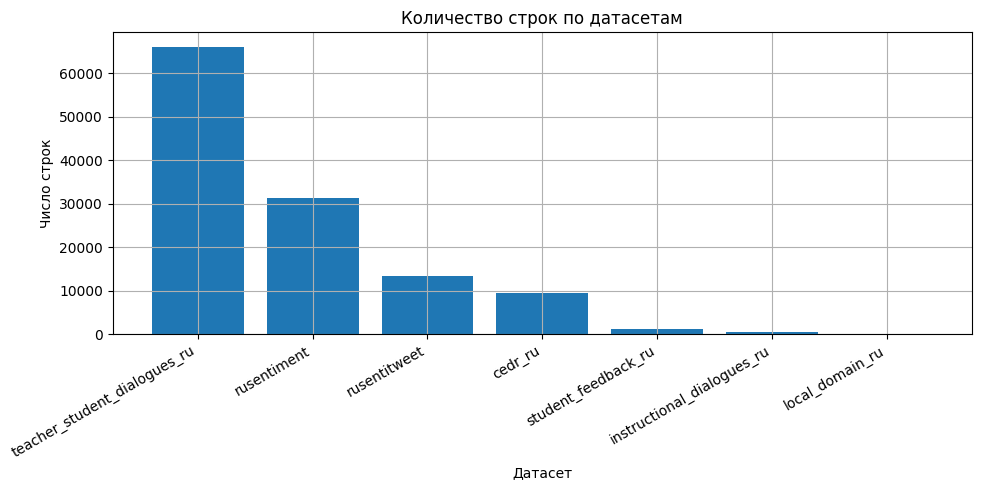

In [ ]:
plot_df = dataset_passports_df.sort_values("rows", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["dataset_name"], plot_df["rows"])
plt.title("Количество строк по датасетам")
plt.xlabel("Датасет")
plt.ylabel("Число строк")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "rows_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. Визуализация: средняя длина текстов

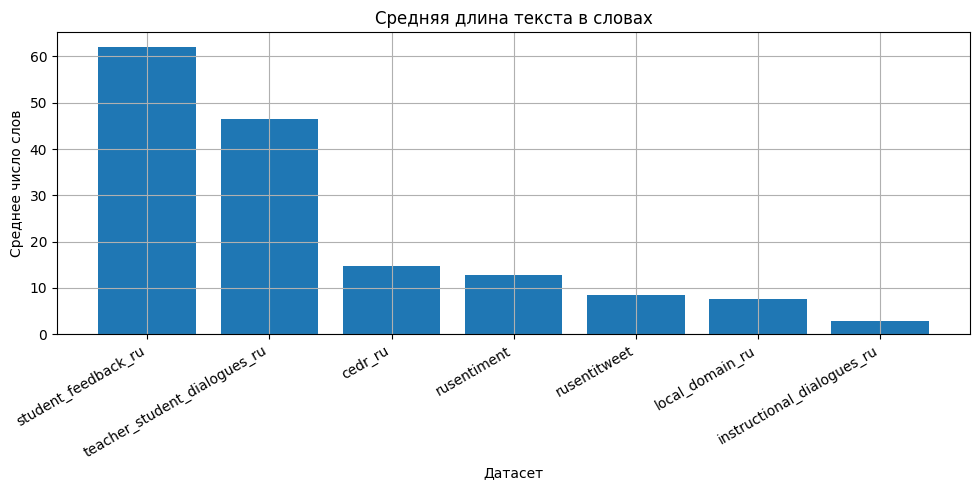

In [ ]:
plot_len_df = quality_df.sort_values("mean_words", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_len_df["dataset_name"], plot_len_df["mean_words"])
plt.title("Средняя длина текста в словах")
plt.xlabel("Датасет")
plt.ylabel("Среднее число слов")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "mean_words_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

## 18. Управленческий вывод: роль каждого датасета в проекте

In [ ]:
decision_rows = [
    {
        "dataset_name": "rusentiment",
        "role_in_project": "основной базовый русскоязычный sentiment-корпус",
        "use_in_next_steps": "идёт в 02_data_preparation и затем в 03_build_target_dataset",
        "notes": "основной 3-классовый источник; в preparation надо оставить только целевые классы",
    },
    {
        "dataset_name": "rusentitweet",
        "role_in_project": "дополнительный русскоязычный sentiment-корпус",
        "use_in_next_steps": "идёт в 02_data_preparation, но требует усиленной очистки",
        "notes": "много URL, mentions и твиттерного шума; не прямой аналог тьюторского чата",
    },
    {
        "dataset_name": "cedr_ru",
        "role_in_project": "дополнительный русскоязычный emotional corpus",
        "use_in_next_steps": "анализируем, но не смешиваем автоматически с 3-классовой тональностью",
        "notes": "полезный русский эмоциональный источник; многометочная структура labels требует отдельного обращения",
    },
    {
        "dataset_name": "student_feedback_ru",
        "role_in_project": "доменный образовательный аспектный корпус",
        "use_in_next_steps": "идёт в анализ предметной области и как доменно близкий слой",
        "notes": "это не обычный sentiment-корпус, а aspect-based отзывы студентов",
    },
    {
        "dataset_name": "instructional_dialogues_ru",
        "role_in_project": "вспомогательный диалоговый источник",
        "use_in_next_steps": "используем только как небольшой auxiliary source",
        "notes": "в текущем виде содержит слишком короткие и повторяющиеся реплики; не должен быть ядром целевого датасета",
    },
    {
        "dataset_name": "teacher_student_dialogues_ru",
        "role_in_project": "основной доменно близкий диалоговый источник",
        "use_in_next_steps": "очень важен для анализа структуры будущих сообщений тьютора и студента",
        "notes": "сейчас это самый сильный диалоговый аналог для вашей предметной области",
    },
    {
        "dataset_name": "local_domain_ru",
        "role_in_project": "будущий собственный целевой корпус ИС Тьюторы",
        "use_in_next_steps": "пока только шаблон, но в будущем это самый ценный источник",
        "notes": "сюда должны попасть реальные тексты тьюторов и студентов",
    },
]

decision_df = pd.DataFrame(decision_rows)
display(decision_df)

,dataset_name,role_in_project,use_in_next_steps,notes
0,rusentiment,основной базовый русскоязычный sentiment-корпус,идёт в 02_data_preparation и затем в 03_build_target_dataset,основной 3-классовый источник; в preparation надо оставить только целевые классы
1,rusentitweet,дополнительный русскоязычный sentiment-корпус,"идёт в 02_data_preparation, но требует усиленной очистки","много URL, mentions и твиттерного шума; не прямой аналог тьюторского чата"
2,cedr_ru,дополнительный русскоязычный emotional corpus,"анализируем, но не смешиваем автоматически с 3-классовой тональностью",полезный русский эмоциональный источник; многометочная структура labels требует отдельного обращения
3,student_feedback_ru,доменный образовательный аспектный корпус,идёт в анализ предметной области и как доменно близкий слой,"это не обычный sentiment-корпус, а aspect-based отзывы студентов"
4,instructional_dialogues_ru,вспомогательный диалоговый источник,используем только как небольшой auxiliary source,в текущем виде содержит слишком короткие и повторяющиеся реплики; не должен быть ядром целевого датасета
5,teacher_student_dialogues_ru,основной доменно близкий диалоговый источник,очень важен для анализа структуры будущих сообщений тьютора и студента,сейчас это самый сильный диалоговый аналог для вашей предметной области
6,local_domain_ru,будущий собственный целевой корпус ИС Тьюторы,"пока только шаблон, но в будущем это самый ценный источник",сюда должны попасть реальные тексты тьюторов и студентов


## 19. Сохраняем отчёты этапа Data Understanding

In [ ]:
registry_df.to_csv(SOURCE_PASSPORTS_DIR / "dataset_registry.csv", index=False)
inventory_df.to_csv(SOURCE_PASSPORTS_DIR / "raw_inventory.csv", index=False)
file_passports_df.to_csv(SOURCE_PASSPORTS_DIR / "file_passports.csv", index=False)
dataset_passports_df.to_csv(SOURCE_PASSPORTS_DIR / "dataset_passports.csv", index=False)
decision_df.to_csv(SOURCE_PASSPORTS_DIR / "dataset_role_decisions.csv", index=False)

summary_basic.to_csv(QC_REPORTS_DIR / "summary_basic.csv", index=False)
quality_df.to_csv(QC_REPORTS_DIR / "quality_audit.csv", index=False)
noise_audit_df.to_csv(QC_REPORTS_DIR / "noise_audit.csv", index=False)
split_df.to_csv(QC_REPORTS_DIR / "split_audit.csv", index=False)
split_pivot_df.to_csv(QC_REPORTS_DIR / "split_pivot.csv", index=False)
mapped_share_df.to_csv(QC_REPORTS_DIR / "mapped_share.csv", index=False)

if not raw_label_distribution.empty:
    raw_label_distribution.to_csv(QC_REPORTS_DIR / "raw_label_distribution.csv", index=False)

if not target_label_distribution.empty:
    target_label_distribution.to_csv(QC_REPORTS_DIR / "target_label_distribution.csv", index=False)

if not cedr_label_summary_df.empty:
    cedr_label_summary_df.to_csv(QC_REPORTS_DIR / "cedr_label_summary.csv", index=False)

if not student_feedback_aspects_df.empty:
    student_feedback_aspects_df.to_csv(QC_REPORTS_DIR / "student_feedback_aspects.csv", index=False)

if not role_summary_df.empty:
    role_summary_df.to_csv(QC_REPORTS_DIR / "role_summary.csv", index=False)

if not dialogue_structure_df.empty:
    dialogue_structure_df.to_csv(QC_REPORTS_DIR / "dialogue_structure.csv", index=False)

if not suspicious_df.empty:
    suspicious_df.to_csv(QC_REPORTS_DIR / "suspicious_rows_sample.csv", index=False)

if not duplicates_sample_df.empty:
    duplicates_sample_df.to_csv(QC_REPORTS_DIR / "duplicates_sample.csv", index=False)

if not load_errors_df.empty:
    load_errors_df.to_csv(QC_REPORTS_DIR / "load_errors.csv", index=False)

print("Отчёты сохранены:")
print(" -", SOURCE_PASSPORTS_DIR)
print(" -", QC_REPORTS_DIR)
print(" -", FIGURES_DIR)

Отчёты сохранены:
 - /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/source_passports
 - /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports
 - /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports/figures


In [ ]:
final_summary = {
    "datasets_in_registry": len(DATASET_REGISTRY),
    "datasets_loaded": int(dataset_passports_df["dataset_name"].nunique()),
    "total_rows_seen": int(dataset_passports_df["rows"].sum()),
    "source_passports_dir": str(SOURCE_PASSPORTS_DIR),
    "qc_reports_dir": str(QC_REPORTS_DIR),
    "figures_dir": str(FIGURES_DIR),
}

final_summary

{'datasets_in_registry': 7,
 'datasets_loaded': 7,
 'total_rows_seen': 121708,
 'source_passports_dir': '/content/drive/MyDrive/tutors_sentiment_project/02_data_interim/source_passports',
 'qc_reports_dir': '/content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports',
 'figures_dir': '/content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports/figures'}